In [1]:
"""
Heart Disease Prediction System
================================
Dataset : UCI Heart Disease (heart_disease_uci.csv)
Subset  : Cleveland only  — 304 rows
Features: 11 clinical inputs (ca and thal dropped due to missingness)
Target  : Binary — 0 = no disease, 1 = disease present
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print("✓ Libraries imported")

✓ Libraries imported


In [2]:
print("=" * 55)
print(" HEART DISEASE PREDICTION — UCI Cleveland Dataset")
print("=" * 55)

# Load the combined UCI file
df_raw = pd.read_csv('heart_disease_uci.csv')
print(f"\n[LOAD] Raw file shape      : {df_raw.shape}")
print(f"[LOAD] Datasets available  : {df_raw['dataset'].unique().tolist()}")

# Keep Cleveland only — the standard 303-row benchmark dataset
df = df_raw[df_raw['dataset'] == 'Cleveland'].copy().reset_index(drop=True)
print(f"[LOAD] Cleveland rows      : {len(df)}")

 HEART DISEASE PREDICTION — UCI Cleveland Dataset

[LOAD] Raw file shape      : (920, 16)
[LOAD] Datasets available  : ['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
[LOAD] Cleveland rows      : 304


In [3]:
# id       — row identifier, not a feature
# dataset  — we filtered already
# ca       — 5 missing values; also excluded from our 11-feature model
# thal     — 3 missing values; also excluded from our 11-feature model
df = df.drop(columns=['id', 'dataset', 'ca', 'thal'])

# Rename thalch → thalach (standard UCI column name)
df = df.rename(columns={'thalch': 'thalach'})

print(f"\n[CLEAN] Shape after column drop : {df.shape}")
print(f"[CLEAN] Remaining columns: {df.columns.tolist()}")


[CLEAN] Shape after column drop : (304, 12)
[CLEAN] Remaining columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'num']


In [4]:
# sex: Male=1, Female=0
df['sex'] = (df['sex'] == 'Male').astype(int)

# cp (chest pain type) — 0 to 3
cp_map = {
    'typical angina'  : 0,
    'atypical angina' : 1,
    'non-anginal'     : 2,
    'asymptomatic'    : 3
}
df['cp'] = df['cp'].map(cp_map)

# fbs — fasting blood sugar > 120 mg/dL: True=1, False=0
df['fbs'] = df['fbs'].map({True: 1, False: 0}).astype(float)

# exang — exercise-induced angina: True=1, False=0
df['exang'] = df['exang'].map({True: 1, False: 0}).astype(float)

# restecg — 0, 1, 2
restecg_map = {
    'normal'          : 0,
    'st-t abnormality': 1,
    'lv hypertrophy'  : 2
}
df['restecg'] = df['restecg'].map(restecg_map)

# slope — 0, 1, 2
slope_map = {
    'upsloping'  : 0,
    'flat'       : 1,
    'downsloping': 2
}
df['slope'] = df['slope'].map(slope_map)

# Binarise target: num 0 = no disease, 1-4 = disease present
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

print(f"\n[ENCODE] Encoding complete.")
print(f"[ENCODE] Missing values remaining:")
print(df.isnull().sum().to_string())


[ENCODE] Encoding complete.
[ENCODE] Missing values remaining:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       1
target      0


In [5]:
# Only 'slope' has 1 missing row. Fill with mode (most common value).

for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        fill_val = df[col].mode()[0]
        df[col] = df[col].fillna(fill_val)
        print(f"[IMPUTE] {col}: filled {n_missing} NaN → {fill_val} (mode)")

print(f"\n[IMPUTE] Final missing: {df.isnull().sum().sum()}")
print(f"[IMPUTE] Final shape  : {df.shape}")

[IMPUTE] slope: filled 1 NaN → 0.0 (mode)

[IMPUTE] Final missing: 0
[IMPUTE] Final shape  : (304, 12)



[EDA] Target distribution:
target
0    165
1    139

[EDA] Summary statistics:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach   exang  oldpeak   slope
count  304.00  304.00  304.00    304.00  304.00  304.00   304.00   304.00  304.00   304.00  304.00
mean    54.35    0.68    2.15    131.68  246.32    0.15     0.99   149.72    0.33     1.04    0.60
std      9.15    0.47    0.96     17.57   52.11    0.36     1.00    22.93    0.47     1.16    0.62
min     28.00    0.00    0.00     94.00  126.00    0.00     0.00    71.00    0.00     0.00    0.00
25%     47.75    0.00    2.00    120.00  211.00    0.00     0.00   133.75    0.00     0.00    0.00
50%     55.50    1.00    2.00    130.00  240.50    0.00     1.00   153.00    0.00     0.80    1.00
75%     61.00    1.00    3.00    140.00  275.00    0.00     2.00   166.00    1.00     1.60    1.00
max     77.00    1.00    3.00    200.00  564.00    1.00     2.00   202.00    1.00     6.20    2.00

[EDA] Saved: eda_plots.png


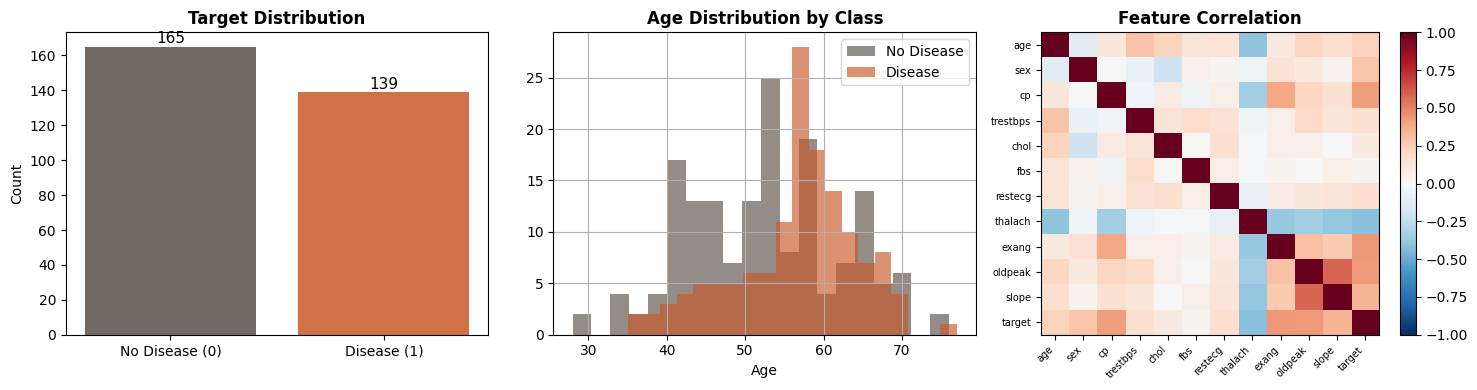

In [6]:
FEATURE_COLS = ['age','sex','cp','trestbps','chol','fbs',
                'restecg','thalach','exang','oldpeak','slope']

print(f"\n[EDA] Target distribution:")
print(df['target'].value_counts().to_string())
print(f"\n[EDA] Summary statistics:")
print(df[FEATURE_COLS].describe().round(2).to_string())

# Plot 1: Target balance
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

target_counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values,
            color=['#5A4E47', '#C85828'], alpha=0.85)
axes[0].set_title('Target Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=11)

# Plot 2: Age distribution by class
df[df['target'] == 0]['age'].hist(ax=axes[1], bins=20, alpha=0.65,
                                   color='#5A4E47', label='No Disease')
df[df['target'] == 1]['age'].hist(ax=axes[1], bins=20, alpha=0.65,
                                   color='#C85828', label='Disease')
axes[1].set_title('Age Distribution by Class', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

# Plot 3: Correlation heatmap
corr = df[FEATURE_COLS + ['target']].corr()
im = axes[2].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[2].set_xticks(range(len(corr.columns)))
axes[2].set_yticks(range(len(corr.columns)))
axes[2].set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=7)
axes[2].set_yticklabels(corr.columns, fontsize=7)
axes[2].set_title('Feature Correlation', fontweight='bold')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
print("\n[EDA] Saved: eda_plots.png")
plt.show()

In [7]:
X = df[FEATURE_COLS]
y = df['target']

# Stratified split: keeps class ratio the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n[SPLIT] Train size : {len(X_train)} samples")
print(f"[SPLIT] Test size  : {len(X_test)} samples")
print(f"[SPLIT] Train class balance: {y_train.value_counts().to_dict()}")
print(f"[SPLIT] Test  class balance: {y_test.value_counts().to_dict()}")


[SPLIT] Train size : 243 samples
[SPLIT] Test size  : 61 samples
[SPLIT] Train class balance: {0: 132, 1: 111}
[SPLIT] Test  class balance: {0: 33, 1: 28}


In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\n[SCALE] Feature means  : {[round(m,4) for m in scaler.mean_]}")
print(f"[SCALE] Feature stds   : {[round(s,4) for s in scaler.scale_]}")


[SCALE] Feature means  : [np.float64(54.4239), np.float64(0.679), np.float64(2.144), np.float64(131.0823), np.float64(250.5021), np.float64(0.1481), np.float64(0.9671), np.float64(149.8807), np.float64(0.3251), np.float64(0.9926), np.float64(0.5844)]
[SCALE] Feature stds   : [np.float64(8.9795), np.float64(0.4669), np.float64(0.9686), np.float64(17.523), np.float64(52.571), np.float64(0.3552), np.float64(0.9974), np.float64(22.7344), np.float64(0.4684), np.float64(1.1199), np.float64(0.612)]


In [9]:
# Logistic Regression — C=0.1 adds regularisation to prevent overfitting
lr = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000, random_state=42)

# Decision Tree — max_depth=5 prevents memorising the training data
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=4, random_state=42)

# Random Forest — ensemble of 100 trees, each capped at depth 6
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

lr.fit(X_train_s, y_train)
dt.fit(X_train_s, y_train)
rf.fit(X_train_s, y_train)

print("\n[TRAIN] All three models trained.")


[TRAIN] All three models trained.


In [10]:
print("\n" + "=" * 55)
print(" MODEL EVALUATION RESULTS")
print("=" * 55)

results = {}
for name, model in [('Logistic Regression', lr),
                    ('Decision Tree',       dt),
                    ('Random Forest',       rf)]:
    pred   = model.predict(X_test_s)
    prob   = model.predict_proba(X_test_s)[:, 1]
    cv_acc = cross_val_score(model, X_train_s, y_train, cv=5, scoring='accuracy')
    acc    = accuracy_score(y_test, pred)
    f1     = f1_score(y_test, pred)
    auc    = roc_auc_score(y_test, prob)

    # Store with consistent keys (no spaces issues)
    key = name.replace(' ', '_')
    results[key] = {'acc': acc, 'f1': f1, 'auc': auc,
                    'cv': cv_acc.mean(), 'cv_std': cv_acc.std(),
                    'pred': pred, 'prob': prob, 'name': name}

    print(f"\n── {name}")
    print(f"   Test Accuracy : {acc:.2%}")
    print(f"   F1 Score      : {f1:.4f}")
    print(f"   ROC-AUC       : {auc:.4f}")
    print(f"   5-Fold CV Acc : {cv_acc.mean():.2%} ± {cv_acc.std():.2%}")
    print(f"\n   Classification Report:")
    # Remove 'indent' parameter - not supported in older sklearn
    print(classification_report(y_test, pred, target_names=['No Disease', 'Disease']))


 MODEL EVALUATION RESULTS

── Logistic Regression
   Test Accuracy : 86.89%
   F1 Score      : 0.8621
   ROC-AUC       : 0.9502
   5-Fold CV Acc : 76.51% ± 4.19%

   Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.85      0.88        33
     Disease       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


── Decision Tree
   Test Accuracy : 80.33%
   F1 Score      : 0.7931
   ROC-AUC       : 0.8317
   5-Fold CV Acc : 67.50% ± 2.58%

   Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.79      0.81        33
     Disease       0.77      0.82      0.79        28

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



[EVAL] Saved: confusion_matrices.png


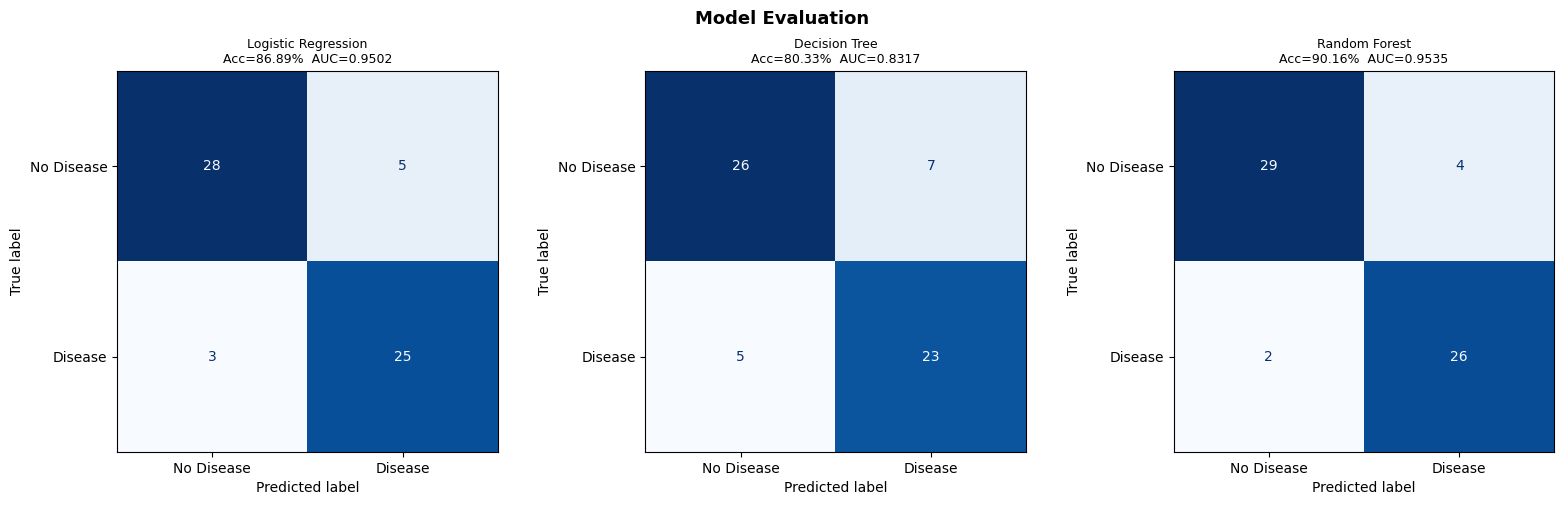

[EVAL] Saved: roc_curves.png


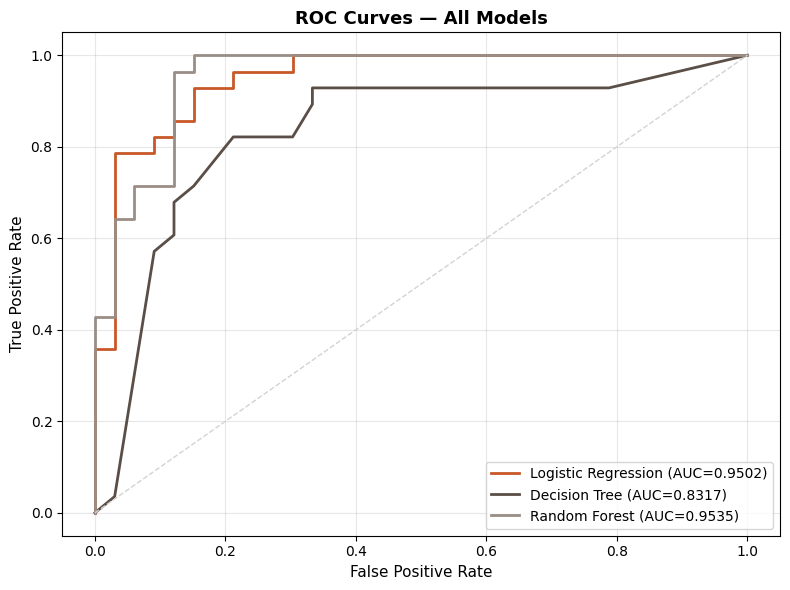

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Evaluation', fontsize=13, fontweight='bold')

# Use the correct keys
model_keys = ['Logistic_Regression', 'Decision_Tree', 'Random_Forest']
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']

for i, (key, name) in enumerate(zip(model_keys, model_names)):
    cm = confusion_matrix(y_test, results[key]['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Disease','Disease']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAcc={results[key]["acc"]:.2%}  AUC={results[key]["auc"]:.4f}',
                      fontsize=9)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
print("\n[EVAL] Saved: confusion_matrices.png")
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
colors = ['#C85828', '#5A4E47', '#9A8D85']
for key, name, color in zip(model_keys, model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, results[key]['prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[key]['auc']:.4f})",
             color=color, linewidth=2)

plt.plot([0,1],[0,1],'--', color='lightgray', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
print("[EVAL] Saved: roc_curves.png")
plt.show()


 LOGISTIC REGRESSION — FEATURE IMPORTANCE

  Intercept : -0.2087

  Feature          Coefficient   |Coefficient|  Direction
  ──────────────  ────────────  ──────────────  ──────────
  sex                   0.6257          0.6257  Risk factor
  cp                    0.5860          0.5860  Risk factor
  oldpeak               0.3934          0.3934  Risk factor
  exang                 0.3381          0.3381  Risk factor
  thalach              -0.3364          0.3364  Protective
  restecg               0.1921          0.1921  Risk factor
  slope                 0.1894          0.1894  Risk factor
  trestbps              0.1871          0.1871  Risk factor
  age                   0.1770          0.1770  Risk factor
  chol                  0.1418          0.1418  Risk factor
  fbs                  -0.0429          0.0429  Protective

[FEAT] Saved: feature_importance.png


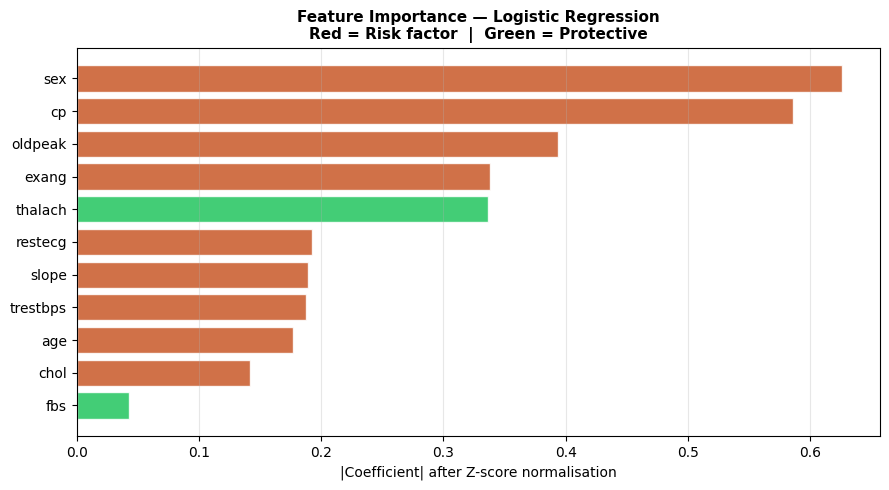

In [12]:
# Absolute coefficient magnitude = feature importance after normalisation
coefs     = lr.coef_[0]
abs_coefs = np.abs(coefs)
feat_imp  = pd.Series(abs_coefs, index=FEATURE_COLS).sort_values(ascending=False)

print("\n" + "=" * 55)
print(" LOGISTIC REGRESSION — FEATURE IMPORTANCE")
print("=" * 55)
print(f"\n  Intercept : {lr.intercept_[0]:.4f}")
print(f"\n  {'Feature':<14}  {'Coefficient':>12}  {'|Coefficient|':>14}  {'Direction'}")
print(f"  {'─'*14}  {'─'*12}  {'─'*14}  {'─'*10}")
for feat in feat_imp.index:
    raw = coefs[FEATURE_COLS.index(feat)]
    direction = 'Risk factor' if raw > 0 else 'Protective'
    print(f"  {feat:<14}  {raw:>12.4f}  {abs(raw):>14.4f}  {direction}")

# Feature importance bar chart
fig, ax = plt.subplots(figsize=(9, 5))
feat_colors = ['#C85828' if coefs[FEATURE_COLS.index(f)] > 0 else '#22c55e'
               for f in feat_imp.index]
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
               color=feat_colors[::-1], alpha=0.85, edgecolor='white')
ax.set_xlabel('|Coefficient| after Z-score normalisation', fontsize=10)
ax.set_title('Feature Importance — Logistic Regression\n'
             'Red = Risk factor  |  Green = Protective', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
print("\n[FEAT] Saved: feature_importance.png")
plt.show()

In [13]:
print("\n" + "=" * 55)
print(" JAVASCRIPT MODEL WEIGHTS")
print(" Copy these into heart-disease-demo.html")
print("=" * 55)

weights_str = str([round(w, 4) for w in lr.coef_[0]])
means_str   = str([round(m, 4) for m in scaler.mean_])
stds_str    = str([round(s, 4) for s in scaler.scale_])

print(f"""
const MODEL = {{
    intercept: {round(lr.intercept_[0], 4)},
    weights: {weights_str},
    means:   {means_str},
    stds:    {stds_str}
}};
""")


 JAVASCRIPT MODEL WEIGHTS
 Copy these into heart-disease-demo.html

const MODEL = {
    intercept: -0.2087,
    weights: [np.float64(0.177), np.float64(0.6257), np.float64(0.586), np.float64(0.1871), np.float64(0.1418), np.float64(-0.0429), np.float64(0.1921), np.float64(-0.3364), np.float64(0.3381), np.float64(0.3934), np.float64(0.1894)],
    means:   [np.float64(54.4239), np.float64(0.679), np.float64(2.144), np.float64(131.0823), np.float64(250.5021), np.float64(0.1481), np.float64(0.9671), np.float64(149.8807), np.float64(0.3251), np.float64(0.9926), np.float64(0.5844)],
    stds:    [np.float64(8.9795), np.float64(0.4669), np.float64(0.9686), np.float64(17.523), np.float64(52.571), np.float64(0.3552), np.float64(0.9974), np.float64(22.7344), np.float64(0.4684), np.float64(1.1199), np.float64(0.612)]
};



In [14]:
print("=" * 55)
print(" HYPERPARAMETER TUNING — Logistic Regression")
print("=" * 55)

param_grid = {'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}
grid_search = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train_s, y_train)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"\n  Best C value : {best_C}")
print(f"  Best CV AUC  : {best_auc:.4f}")
print(f"\n  Grid search results:")
for C_val, score in zip(param_grid['C'],
                         grid_search.cv_results_['mean_test_score']):
    marker = ' ← best' if C_val == best_C else ''
    print(f"    C={C_val:>6}  AUC={score:.4f}{marker}")

 HYPERPARAMETER TUNING — Logistic Regression

  Best C value : 0.01
  Best CV AUC  : 0.8485

  Grid search results:
    C= 0.001  AUC=0.8441
    C=  0.01  AUC=0.8485 ← best
    C=   0.1  AUC=0.8434
    C=   0.5  AUC=0.8419
    C=   1.0  AUC=0.8398
    C=   5.0  AUC=0.8384
    C=  10.0  AUC=0.8388


In [15]:
print("\n" + "=" * 55)
print(" FINAL SUMMARY")
print("=" * 55)

# Find best model
best_key = max(results, key=lambda k: results[k]['auc'])
best_name = results[best_key]['name']

print(f"""
  Dataset        : UCI Heart Disease — Cleveland subset
  Samples        : {len(df)} rows
  Features       : {len(FEATURE_COLS)} clinical inputs
  Train/Test     : 80% / 20% stratified

  Model          : Accuracy   F1      AUC
  ─────────────────────────────────────────
  Logistic Reg.  : {results['Logistic_Regression']['acc']:.2%}    {results['Logistic_Regression']['f1']:.4f}  {results['Logistic_Regression']['auc']:.4f}
  Decision Tree  : {results['Decision_Tree']['acc']:.2%}    {results['Decision_Tree']['f1']:.4f}  {results['Decision_Tree']['auc']:.4f}
  Random Forest  : {results['Random_Forest']['acc']:.2%}    {results['Random_Forest']['f1']:.4f}  {results['Random_Forest']['auc']:.4f}

  Best model (by AUC): {best_name}

  Deployed       : Logistic Regression — selected for interpretability
                   and calibrated probability outputs.

  Output files   :
    eda_plots.png          — EDA visualisations
    confusion_matrices.png — Confusion matrices (all 3 models)
    roc_curves.png         — ROC curves
    feature_importance.png — LR feature importance
""")


 FINAL SUMMARY

  Dataset        : UCI Heart Disease — Cleveland subset
  Samples        : 304 rows
  Features       : 11 clinical inputs
  Train/Test     : 80% / 20% stratified

  Model          : Accuracy   F1      AUC
  ─────────────────────────────────────────
  Logistic Reg.  : 86.89%    0.8621  0.9502
  Decision Tree  : 80.33%    0.7931  0.8317
  Random Forest  : 90.16%    0.8966  0.9535

  Best model (by AUC): Random Forest

  Deployed       : Logistic Regression — selected for interpretability
                   and calibrated probability outputs.

  Output files   :
    eda_plots.png          — EDA visualisations
    confusion_matrices.png — Confusion matrices (all 3 models)
    roc_curves.png         — ROC curves
    feature_importance.png — LR feature importance

